# Census Income: Exploratory Data Analysis (EDA)

**Goal:** identify characteristics associated with earning **more vs less than \$50,000/year**.  
**Target:** `income_over_50k` derived from the dataset’s final column (`income`).

This notebook focuses on:
- schema checks (including headerless CSV handling)
- numerical / categorical EDA
- relationships between features and target
- a concrete plan for data prep, modelling, assessment, and next steps


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("census_income_learn.csv", header=None)

In [3]:
columns = [
    "age","class_of_worker","industry_code","occupation_code","education",
    "wage_per_hour","enrolled_in_edu","marital_status","major_industry_code",
    "major_occupation_code","race","hispanic_origin","sex",
    "member_of_labor_union","reason_for_unemployment","employment_stat",
    "capital_gains","capital_losses","dividends","tax_filer_status",
    "region","state","household_status","household_summary",
    "instance_weight","migration_code","migration_reg","migration_msa",
    "migration_within_state","migration_sunbelt","num_persons_employer",
    "family_members_under_18","country_of_birth_father",
    "country_of_birth_mother","country_of_birth_self","citizenship",
    "own_business","fill_inc_questionnaire","veterans_benefits",
    "weeks_worked","year","income"
]

df.columns = columns

In [4]:
df.head()

,age,class_of_worker,industry_code,occupation_code,education,wage_per_hour,enrolled_in_edu,marital_status,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business,fill_inc_questionnaire,veterans_benefits,weeks_worked,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [5]:
# Target construction: strip spaces, then map "50000+." => 1 else 0
df["income_clean"] = df["income"].astype(str).str.strip()
df["income_over_50k"] = (df["income_clean"].str.startswith("50000+")).astype(int)

In [6]:
# Basic sanity checks
df["income_clean"].value_counts()

income_clean
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

In [7]:
df.head(3)

,age,class_of_worker,industry_code,occupation_code,education,wage_per_hour,enrolled_in_edu,marital_status,major_industry_code,major_occupation_code,...,country_of_birth_self,citizenship,own_business,fill_inc_questionnaire,veterans_benefits,weeks_worked,year,income,income_clean,income_over_50k
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.,- 50000.,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.,- 50000.,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.,- 50000.,0


## 1) High-level dataset overview


In [8]:
df.shape

(199523, 44)

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,199523.0,NaN,NaN,NaN,34.494199,22.310895,0.0,15.0,33.0,50.0,90.0
class_of_worker,199523,9,Not in universe,100245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry_code,199523.0,NaN,NaN,NaN,15.35232,18.067129,0.0,0.0,0.0,33.0,51.0
occupation_code,199523.0,NaN,NaN,NaN,11.306556,14.454204,0.0,0.0,0.0,26.0,46.0
education,199523,17,High school graduate,48407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wage_per_hour,199523.0,NaN,NaN,NaN,55.426908,274.896454,0.0,0.0,0.0,0.0,9999.0
enrolled_in_edu,199523,3,Not in universe,186943,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,199523,7,Never married,86485,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_industry_code,199523,24,Not in universe or children,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
major_occupation_code,199523,15,Not in universe,100684,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 44 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      199523 non-null  int64  
 1   class_of_worker          199523 non-null  object 
 2   industry_code            199523 non-null  int64  
 3   occupation_code          199523 non-null  int64  
 4   education                199523 non-null  object 
 5   wage_per_hour            199523 non-null  int64  
 6   enrolled_in_edu          199523 non-null  object 
 7   marital_status           199523 non-null  object 
 8   major_industry_code      199523 non-null  object 
 9   major_occupation_code    199523 non-null  object 
 10  race                     199523 non-null  object 
 11  hispanic_origin          199523 non-null  object 
 12  sex                      199523 non-null  object 
 13  member_of_labor_union    199523 non-null  object 
 14  reas

In [11]:
df.nunique().sort_values()

income_over_50k                2
income                         2
income_clean                   2
year                           2
sex                            2
migration_within_state         3
own_business                   3
veterans_benefits              3
member_of_labor_union          3
fill_inc_questionnaire         3
enrolled_in_edu                3
migration_sunbelt              4
citizenship                    5
family_members_under_18        5
race                           5
region                         6
reason_for_unemployment        6
tax_filer_status               6
marital_status                 7
num_persons_employer           7
employment_stat                8
household_summary              8
class_of_worker                9
migration_reg                  9
hispanic_origin               10
migration_code                10
migration_msa                 10
major_occupation_code         15
education                     17
major_industry_code           24
household_

In [12]:
for column in df.columns:
    print(f"column: {column}", df[column].unique())

column: age [73 58 18  9 10 48 42 28 47 34  8 32 51 46 26 13 39 16 35 12 27 56 55  2
  1 37  4 63 25 81 11 30  7 66 84 52  5 36 72 61 41 90 49  6  0 33 57 50
 24 17 53 40 54 22 29 85 38 76 21 31 74 19 15  3 43 68 71 45 62 23 69 75
 44 59 60 64 65 70 67 78 20 14 83 86 89 77 79 82 80 87 88]
column: class_of_worker [' Not in universe' ' Self-employed-not incorporated' ' Private'
 ' Local government' ' Federal government' ' Self-employed-incorporated'
 ' State government' ' Never worked' ' Without pay']
column: industry_code [ 0  4 40 34 43 37 24 39 12 35 45  3 19 29 32 48 33 23 44 36 31 30 41  5
 11  9 42  6 18 50  2  1 26 47 16 14 22 17  7  8 25 46 27 15 13 49 38 21
 28 20 51 10]
column: occupation_code [ 0 34 10  3 40 26 37 31 12 36 41 22  2 35 25 23 42  8 19 29 27 16 33 13
 18  9 17 39 32 11 30 38 20  7 21 44 24 43 28  4  1  6 45 14  5 15 46]
column: education [' High school graduate' ' Some college but no degree' ' 10th grade'
 ' Children' ' Bachelors degree(BA AB BS)'
 ' Masters degr

In [13]:
# Missing values 
df.isna().sum().sort_values(ascending=False)

age                        0
class_of_worker            0
instance_weight            0
migration_code             0
migration_reg              0
migration_msa              0
migration_within_state     0
migration_sunbelt          0
num_persons_employer       0
family_members_under_18    0
country_of_birth_father    0
country_of_birth_mother    0
country_of_birth_self      0
citizenship                0
own_business               0
fill_inc_questionnaire     0
veterans_benefits          0
weeks_worked               0
year                       0
income                     0
income_clean               0
household_summary          0
household_status           0
state                      0
race                       0
industry_code              0
occupation_code            0
education                  0
wage_per_hour              0
enrolled_in_edu            0
marital_status             0
major_industry_code        0
major_occupation_code      0
hispanic_origin            0
region        

In [14]:
(df == "Not in universe").sum().sort_values(ascending=False)

age                        0
class_of_worker            0
instance_weight            0
migration_code             0
migration_reg              0
migration_msa              0
migration_within_state     0
migration_sunbelt          0
num_persons_employer       0
family_members_under_18    0
country_of_birth_father    0
country_of_birth_mother    0
country_of_birth_self      0
citizenship                0
own_business               0
fill_inc_questionnaire     0
veterans_benefits          0
weeks_worked               0
year                       0
income                     0
income_clean               0
household_summary          0
household_status           0
state                      0
race                       0
industry_code              0
occupation_code            0
education                  0
wage_per_hour              0
enrolled_in_edu            0
marital_status             0
major_industry_code        0
major_occupation_code      0
hispanic_origin            0
region        

In [15]:
obj_cols = df.select_dtypes(include="object").columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

# Normalise question-mark unknowns
#    (covers '?', ' ?', '? ', etc. after strip it's just '?')
df[obj_cols] = df[obj_cols].replace({"?": "UNKNOWN"})

# 3) collapse common "Not in universe" variants into consistent labels
universe_map = {
    "Not in universe": "NOT_IN_UNIVERSE",
    "Not in universe or children": "NOT_IN_UNIVERSE_OR_CHILDREN",
    "Not in universe under 1 year old": "NOT_IN_UNIVERSE_UNDER_1"
}
df[obj_cols] = df[obj_cols].replace(universe_map)

In [16]:
df[obj_cols] = df[obj_cols].replace(
    {
        "NOT_IN_UNIVERSE_OR_CHILDREN": "NOT_IN_UNIVERSE",
        "NOT_IN_UNIVERSE_UNDER_1": "NOT_IN_UNIVERSE",
    }
)

## 3) Numeric EDA

We’ll look at distributions and basic signal:
- age
- weeks_worked
- wage_per_hour
- capital_gains / capital_losses / dividends


In [17]:
numeric_cols = df.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()
numeric_cols

['age',
 'industry_code',
 'occupation_code',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends',
 'instance_weight',
 'num_persons_employer',
 'own_business',
 'veterans_benefits',
 'weeks_worked',
 'year',
 'income_over_50k']

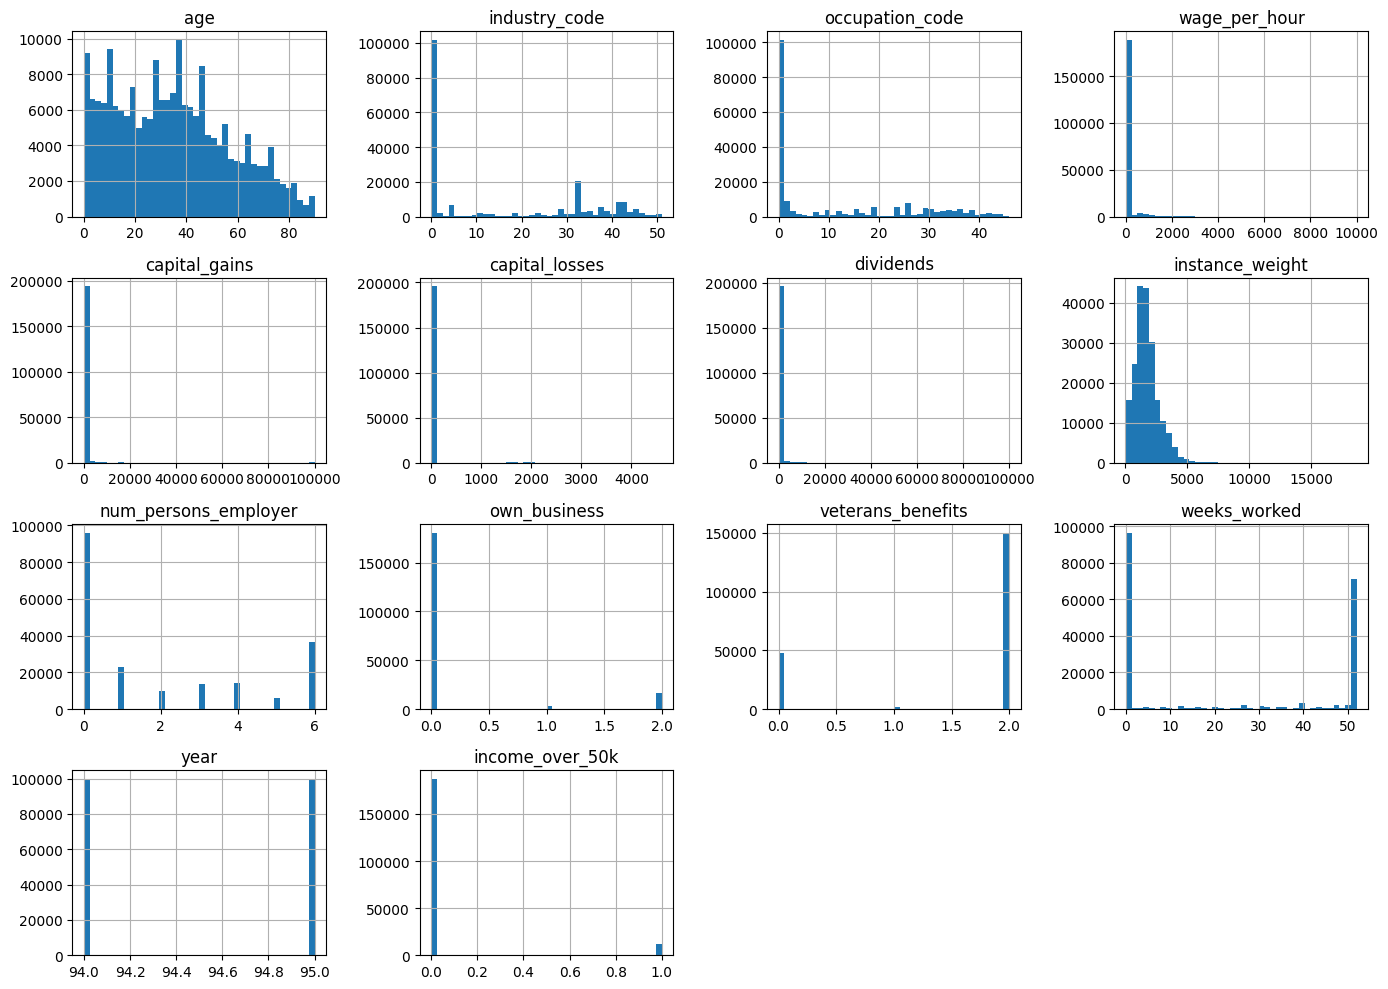

In [18]:
df[numeric_cols].hist(bins=40, figsize=(14,10))
plt.tight_layout()

C:\Users\tjani\AppData\Local\Temp\ipykernel_22704\3761298941.py:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


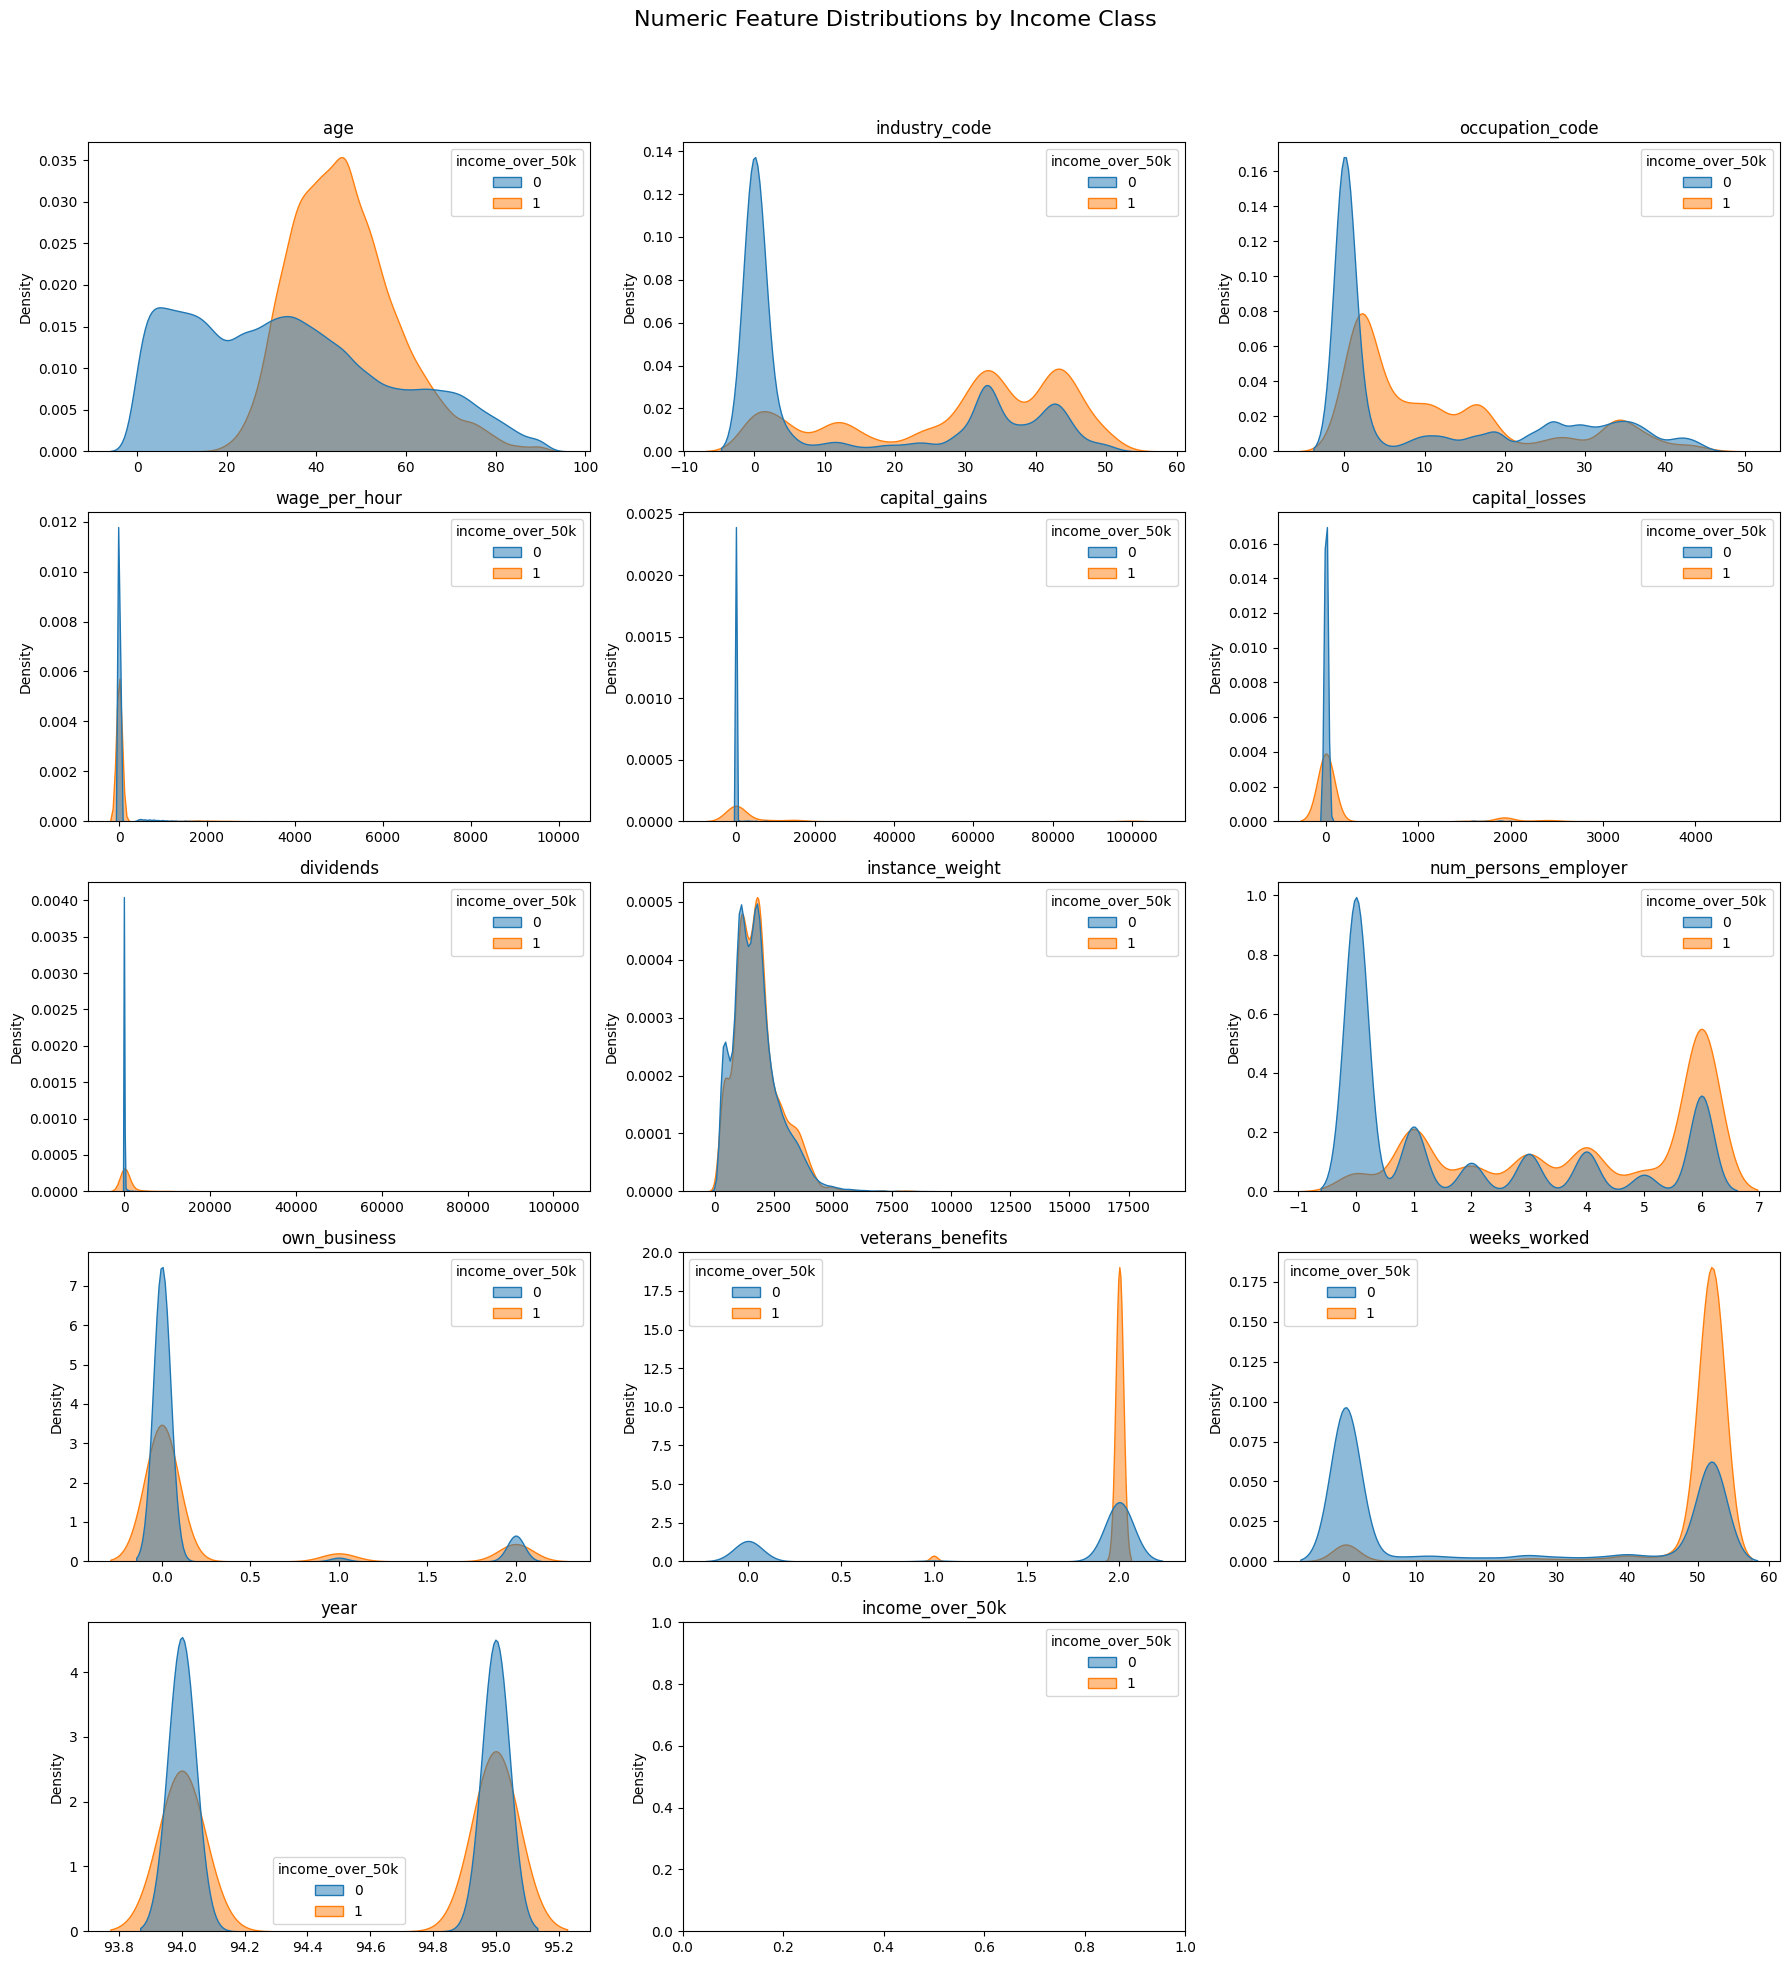

In [19]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue="income_over_50k",
        common_norm=False,
        fill=True,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# Remove empty subplots
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Feature Distributions by Income Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Numeric feature vs target

Compare group summaries for each key numeric feature.


In [20]:

key_nums = ["age","weeks_worked","wage_per_hour","capital_gains","capital_losses","dividends"]

grp = df.groupby("income_over_50k")[key_nums].mean()
grp


,age,weeks_worked,wage_per_hour,capital_gains,capital_losses,dividends
income_over_50k,,,,,,
0,33.715316,21.527762,53.692526,143.848013,27.003730,107.816518
1,46.266193,48.069617,81.640284,4830.930060,193.139557,1553.448070


In [21]:

# Weighted means by target
w = df["instance_weight"].to_numpy()
y = df["income_over_50k"].to_numpy()

weighted_means = {}
for col in key_nums:
    x = df[col].to_numpy()
    weighted_means[col] = {
        "<=50k": float(np.average(x[y==0], weights=w[y==0])),
        ">50k": float(np.average(x[y==1], weights=w[y==1]))
    }

pd.DataFrame(weighted_means).T


,<=50k,>50k
age,33.676008,46.129831
weeks_worked,21.900271,48.163953
wage_per_hour,55.723077,81.373316
capital_gains,144.574620,4781.242068
capital_losses,27.872649,194.792756
dividends,109.484703,1483.940367


## 4) Categorical EDA

We’ll inspect:
- education
- marital_status
- class_of_worker
- major_industry_code
- major_occupation_code
- race / sex


In [22]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['class_of_worker',
 'education',
 'enrolled_in_edu',
 'marital_status',
 'major_industry_code',
 'major_occupation_code',
 'race',
 'hispanic_origin',
 'sex',
 'member_of_labor_union',
 'reason_for_unemployment',
 'employment_stat',
 'tax_filer_status',
 'region',
 'state',
 'household_status',
 'household_summary',
 'migration_code',
 'migration_reg',
 'migration_msa',
 'migration_within_state',
 'migration_sunbelt',
 'family_members_under_18',
 'country_of_birth_father',
 'country_of_birth_mother',
 'country_of_birth_self',
 'citizenship',
 'fill_inc_questionnaire',
 'income',
 'income_clean']

### Categorical feature vs target (weighted rate)

For each category in selected columns, compute weighted proportion earning >50k.


In [23]:
def weighted_rate_by_category(data: pd.DataFrame, col: str, min_count: int = 2000):
    tmp = data[[col,"income_over_50k","instance_weight"]].copy()
    tmp[col] = tmp[col].astype(str).str.strip()
    grp = tmp.groupby(col).agg(
        count=("income_over_50k","size"),
        wcount=("instance_weight","sum"),
        w_rate_over_50k=("income_over_50k", lambda s: np.average(s, weights=tmp.loc[s.index,"instance_weight"]))
    ).reset_index()
    grp = grp[grp["count"] >= min_count].sort_values("w_rate_over_50k", ascending=False)
    return grp

for col in ["education","marital_status","class_of_worker","tax_filer_status",
            "major_occupation_code"]:
    display(weighted_rate_by_category(df, col, min_count=2000).head(15))


,education,count,wcount,w_rate_over_50k
14,Masters degree(MA MS MEng MEd MSW MBA),6541,11475673.95,0.315950
9,Bachelors degree(BA AB BS),19865,35738476.21,0.203474
7,Associates degree-academic program,4363,7923965.51,0.096324
8,Associates degree-occup /vocational,5358,9186755.06,0.075936
16,Some college but no degree,27820,50296154.39,0.064957
12,High school graduate,48407,85589219.42,0.037622
2,12th grade no diploma,2126,3760879.44,0.014814
1,11th grade,6876,12290046.29,0.010311
5,7th and 8th grade,8007,13126143.41,0.008839
0,10th grade,7557,13272987.31,0.008342


,marital_status,count,wcount,w_rate_over_50k
2,Married-civilian spouse present,84222,1.444042e+08,0.119349
0,Divorced,12710,2.317747e+07,0.080676
5,Separated,3460,6.448192e+06,0.050372
6,Widowed,10463,1.754912e+07,0.031974
4,Never married,86485,1.519181e+08,0.013660


,class_of_worker,count,wcount,w_rate_over_50k
5,Self-employed-incorporated,3265,5.652140e+06,0.362642
0,Federal government,2925,5.053904e+06,0.210753
6,Self-employed-not incorporated,8445,1.451549e+07,0.132921
7,State government,4227,7.165721e+06,0.117224
1,Local government,7784,1.374835e+07,0.112191
4,Private,72028,1.291665e+08,0.102234
2,NOT_IN_UNIVERSE,100245,1.708704e+08,0.009402


,tax_filer_status,count,wcount,w_rate_over_50k
2,Joint both under 65,67383,1.156458e+08,0.137532
3,Joint one under 65 & one 65+,3867,6.653446e+06,0.081449
0,Head of household,7426,1.317818e+07,0.060355
5,Single,37421,6.951902e+07,0.059625
1,Joint both 65+,8332,1.435770e+07,0.055546
4,Nonfiler,75094,1.278918e+08,0.000441


,major_occupation_code,count,wcount,w_rate_over_50k
2,Executive admin and managerial,12495,2.219117e+07,0.290557
10,Professional specialty,13940,2.461443e+07,0.254143
12,Sales,11783,2.121534e+07,0.132666
13,Technicians and related support,3018,5.460453e+06,0.119937
8,Precision production craft & repair,10518,1.884325e+07,0.088870
14,Transportation and material moving,4020,7.265852e+06,0.063909
3,Farming forestry and fishing,3146,5.177166e+06,0.043498
5,Machine operators assmblrs & inspctrs,6379,1.133860e+07,0.038257
0,Adm support including clerical,14837,2.635368e+07,0.030261
4,Handlers equip cleaners etc,4127,7.580926e+06,0.017946


## 5) Correlation + quick feature screening (numeric)

This is not the final feature selection step—just to spot obvious signals.


In [24]:
corr = df[numeric_cols + ["income_over_50k"]].corr()

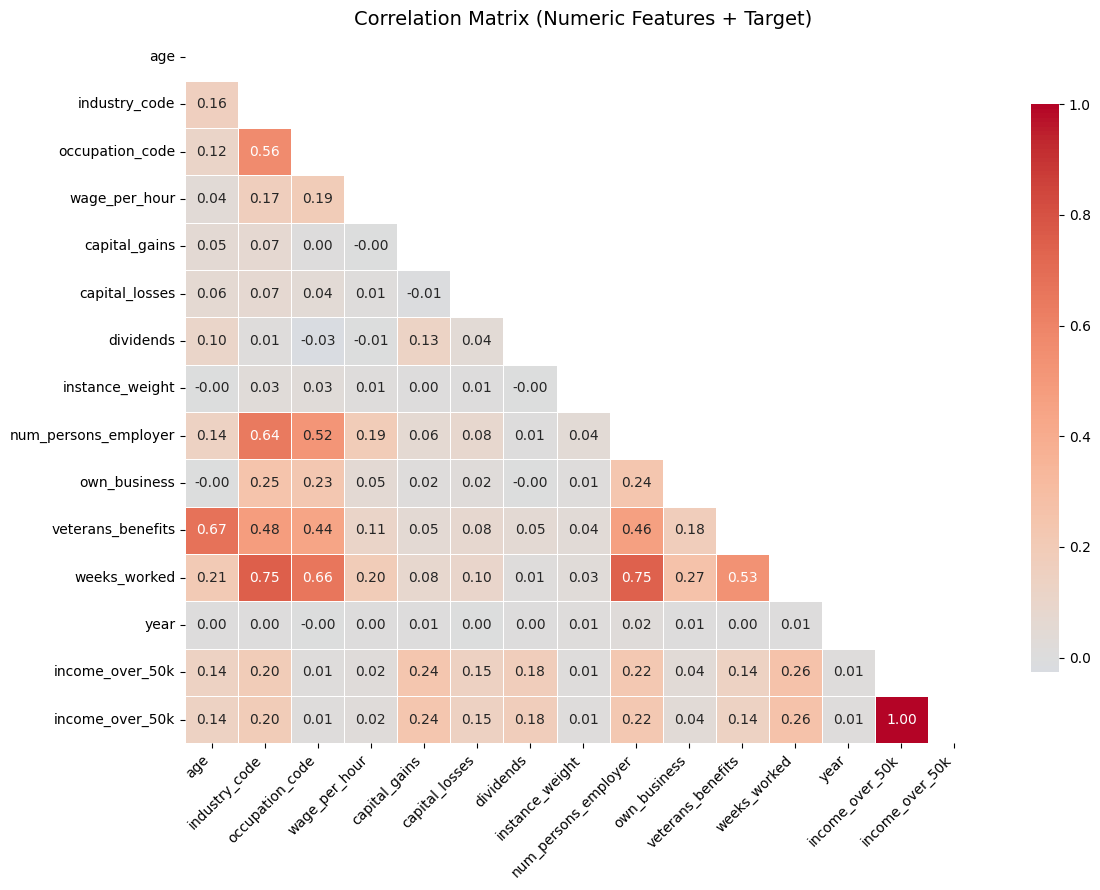

In [25]:
corr = df[numeric_cols + ["income_over_50k"]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Numeric Features + Target)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6) EDA takeaways 

## 7) Detailed next steps (prep, modelling, assessment, results)

### Data Preparation 
1. **Schema enforcement**
   - enforce column names (42 columns), correct dtypes, strip whitespace in categoricals
2. **Target creation**
   - `income_over_50k = 1 if income_clean startswith("50000+"), else 0`
3. **Missingness & placeholders**
   - treat “Not in universe” consistently (keep as its own category vs convert to missing)
4. **Train/test split**
   - stratify on target; keep a fixed random seed
5. **Preprocessing pipeline**
   - numeric: optional scaling
   - categorical: one-hot encoding with `handle_unknown="ignore"`
6. **Weighting**
   - incorporate `instance_weight` into training and metric calculations

### Modelling (competing approaches)
- Baseline: **Logistic Regression** (interpretable; good for insight)
- Alternative: **Gradient boosting** (non-linear interactions; typically best accuracy)
- Alternative: **linear model** with regularisation (fast, stable)

### Model Assessment (what to report)
- Primary: ROC-AUC (weighted), PR-AUC (weighted)
- Secondary: F1, precision, recall, balanced accuracy
- Threshold tuning (business trade-off: FP vs FN)
- Calibration (optional): reliability curve / Brier score

### Results deliverable
- Top drivers (odds ratios / feature importance)
- Clear narrative: “what increases/decreases probability of >50k”
- Caveats: proxy features, bias risk, leakage checks
- Production notes: schema validation, monitoring, drift checks

### Future improvements
- hyperparameter optimisation (random/grid search)
- more robust encodings (target encoding with leakage-safe CV)
- fairness metrics and mitigation plan
- model monitoring & retraining strategy
